# Festa Festum — Dashboard Analitik Vendor
**Data Scientist | Minggu 3**

Visualisasi performa vendor dan proyeksi pendapatan platform untuk keperluan:
- Demo lomba USB Gunadarma
- Slide Financial Projection (Pitch Deck slide 10)
- Panel kontrol vendor (preview)

## 0. Upload Dataset

In [1]:
from google.colab import files
uploaded = files.upload()  # pilih vendors.csv
print('Uploaded:', list(uploaded.keys()))

Saving vendors.csv to vendors.csv
Uploaded: ['vendors.csv']


## 1. Setup & Generate Mock Booking Data

Karena aplikasi belum live, kita buat data simulasi booking yang realistis untuk demo.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
np.random.seed(42)

df_vendors = pd.read_csv('vendors.csv')
df_vendors['price_mid'] = (df_vendors['price_start'] + df_vendors['price_end']) / 2
print(f'Vendor loaded: {len(df_vendors)}')

Vendor loaded: 250


In [3]:
N_BOOKINGS = 1200
MONTHS = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agt','Sep','Okt','Nov','Des']

# Peak bulan: Mar, Jun, Sep, Des
month_weights = [0.06,0.07,0.11,0.08,0.07,0.10,0.07,0.08,0.11,0.08,0.07,0.10]

booking_months  = np.random.choice(range(12), size=N_BOOKINGS, p=month_weights)
booking_vendors = df_vendors.sample(N_BOOKINGS, replace=True).reset_index(drop=True)

df_bookings = pd.DataFrame({
    'booking_id'  : [f'BK-{i+1:04d}' for i in range(N_BOOKINGS)],
    'month'       : booking_months,
    'month_label' : [MONTHS[m] for m in booking_months],
    'vendor_id'   : booking_vendors['vendor_id'].values,
    'vendor_name' : booking_vendors['vendor_name'].values,
    'category'    : booking_vendors['category'].values,
    'city'        : booking_vendors['city'].values,
    'rating'      : booking_vendors['rating'].values,
    'price_mid'   : booking_vendors['price_mid'].values,
})

df_bookings['transaction_value'] = (
    booking_vendors['price_start'].values +
    np.random.uniform(0, 1, N_BOOKINGS) *
    (booking_vendors['price_end'].values - booking_vendors['price_start'].values)
).astype(int)

COMMISSION_RATE = 0.05
SERVICE_FEE     = 15000
df_bookings['commission']   = (df_bookings['transaction_value'] * COMMISSION_RATE).astype(int)
df_bookings['service_fee']  = SERVICE_FEE
df_bookings['platform_rev'] = df_bookings['commission'] + df_bookings['service_fee']

print(f'Mock booking generated: {len(df_bookings)} transaksi')
print(f'Total GMV             : Rp {df_bookings["transaction_value"].sum():,.0f}')
print(f'Total Revenue platform: Rp {df_bookings["platform_rev"].sum():,.0f}')
df_bookings.head()

Mock booking generated: 1200 transaksi
Total GMV             : Rp 4,491,207,330
Total Revenue platform: Rp 242,559,808


,booking_id,month,month_label,vendor_id,vendor_name,category,city,rating,price_mid,transaction_value,commission,service_fee,platform_rev
0,BK-0001,4,Mei,JK-025,Yuwana Kebaya Studio,Sewa Jas/Kebaya,Bekasi,4.6,1625000.0,786653,39332,15000,54332
1,BK-0002,11,Des,FT-004,Dramatis Photography,Fotografer,Depok,4.7,3400000.0,2062949,103147,15000,118147
2,BK-0003,8,Sep,EO-007,Bintang Sejahtera EO,Event Organizer,Bogor,4.4,4500000.0,6839300,341965,15000,356965
3,BK-0004,7,Agt,EO-029,Xclusive Event House,Event Organizer,Tangerang,4.9,16250000.0,13079394,653969,15000,668969
4,BK-0005,2,Mar,JK-039,Merah Putih Attire,Sewa Jas/Kebaya,Tangerang,4.5,1500000.0,1930757,96537,15000,111537


## 2. Booking per Bulan per Kategori

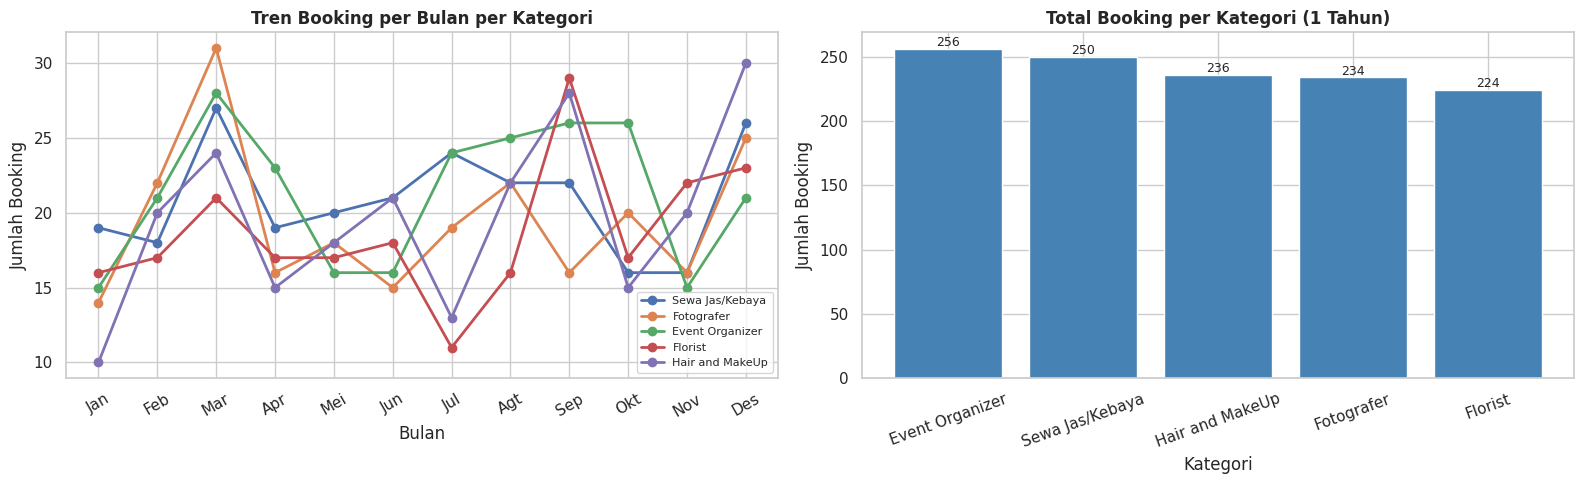

In [4]:
monthly_cat = df_bookings.groupby(['month','month_label','category']).size().reset_index(name='jumlah_booking')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for cat in df_bookings['category'].unique():
    data = monthly_cat[monthly_cat['category']==cat].sort_values('month')
    axes[0].plot(MONTHS, data['jumlah_booking'].values, marker='o', label=cat, linewidth=2)
axes[0].set_title('Tren Booking per Bulan per Kategori', fontweight='bold')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Jumlah Booking')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=30)

total_cat = df_bookings['category'].value_counts()
axes[1].bar(total_cat.index, total_cat.values, color='steelblue')
axes[1].set_title('Total Booking per Kategori (1 Tahun)', fontweight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah Booking')
for i, v in enumerate(total_cat.values):
    axes[1].text(i, v+2, str(v), ha='center', fontsize=9)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 3. Popularitas Kota per Kategori

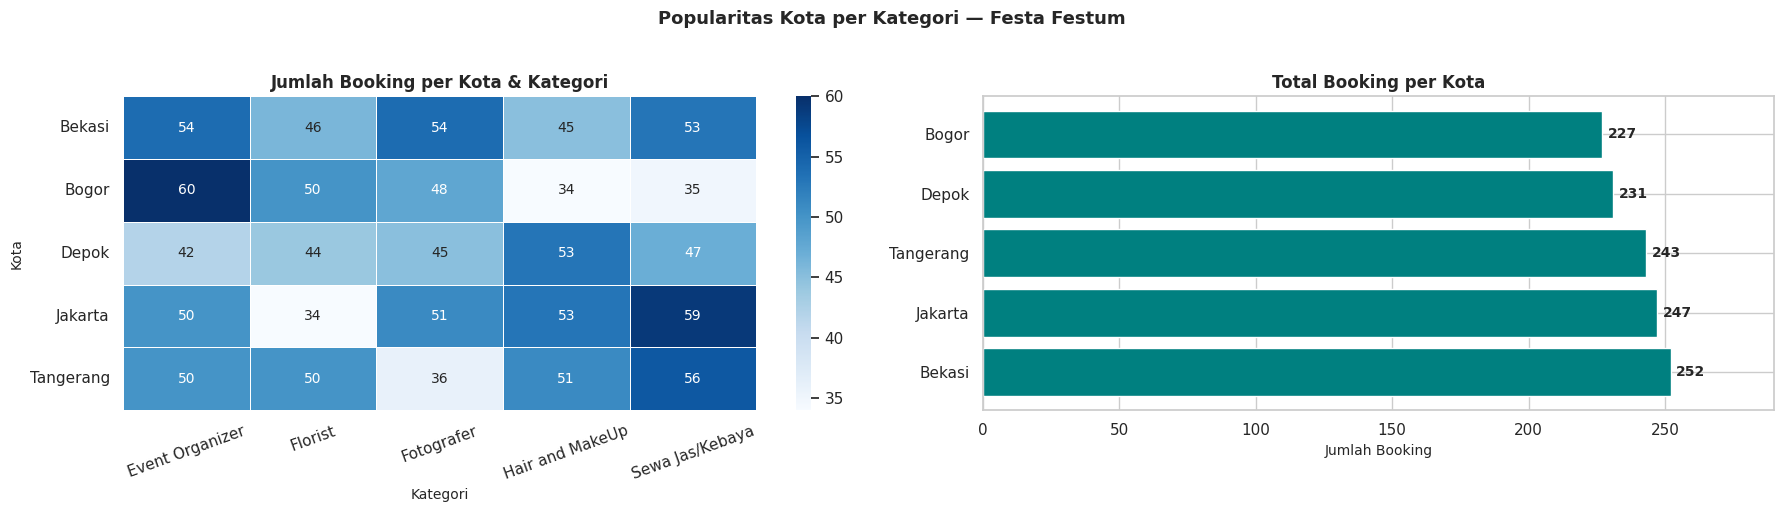

In [8]:
city_cat = df_bookings.groupby(['city', 'category']).size().reset_index(name='jumlah')
pivot_city = city_cat.pivot_table(index='city', columns='category', values='jumlah', fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Heatmap
sns.heatmap(pivot_city.astype(int), annot=True, fmt='d', cmap='Blues', ax=axes[0],
            linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('Jumlah Booking per Kota & Kategori', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Kategori', fontsize=10)
axes[0].set_ylabel('Kota', fontsize=10)
axes[0].tick_params(axis='x', rotation=20)
axes[0].tick_params(axis='y', rotation=0)

# Bar chart horizontal
total_city = df_bookings['city'].value_counts()
bars = axes[1].barh(total_city.index, total_city.values, color='teal', edgecolor='white')
axes[1].set_title('Total Booking per Kota', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Jumlah Booking', fontsize=10)
axes[1].set_xlim(0, total_city.max() * 1.15)
for bar, v in zip(bars, total_city.values):
    axes[1].text(v + 2, bar.get_y() + bar.get_height() / 2,
                 str(v), va='center', fontsize=10, fontweight='bold')

plt.suptitle('Popularitas Kota per Kategori — Festa Festum', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Estimasi Pendapatan Vendor

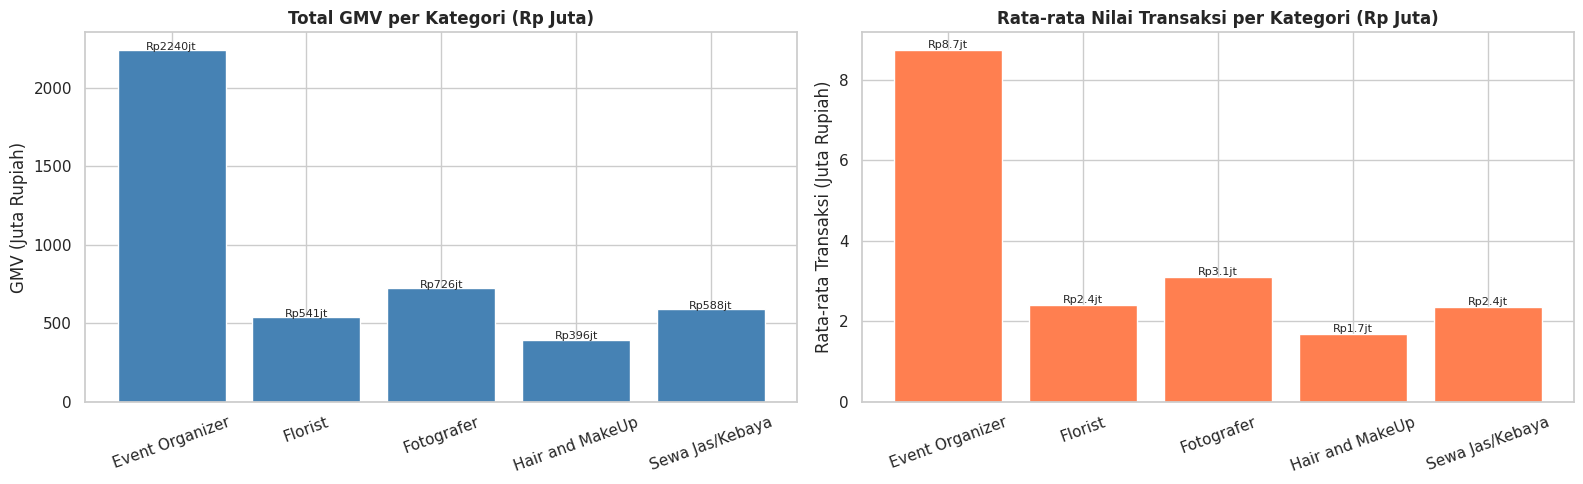


=== Ringkasan Pendapatan Vendor ===
Event Organizer           | Booking: 256 | GMV: Rp2,239,902,197 | Ke Vendor: Rp2,127,907,087
Florist                   | Booking: 224 | GMV: Rp541,396,885 | Ke Vendor: Rp514,327,040
Fotografer                | Booking: 234 | GMV: Rp725,833,652 | Ke Vendor: Rp689,541,969
Hair and MakeUp           | Booking: 236 | GMV: Rp395,999,619 | Ke Vendor: Rp376,199,638
Sewa Jas/Kebaya           | Booking: 250 | GMV: Rp588,074,977 | Ke Vendor: Rp558,671,228


In [9]:
vendor_rev = df_bookings.groupby('category').agg(
    total_booking=('booking_id','count'),
    total_gmv=('transaction_value','sum'),
    rata_gmv=('transaction_value','mean'),
    total_ke_vendor=('transaction_value', lambda x: int(x.sum() * 0.95))
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(vendor_rev['category'], vendor_rev['total_gmv']/1e6, color='steelblue')
axes[0].set_title('Total GMV per Kategori (Rp Juta)', fontweight='bold')
axes[0].set_ylabel('GMV (Juta Rupiah)')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(vendor_rev['total_gmv'].values):
    axes[0].text(i, v/1e6+1, f'Rp{v/1e6:.0f}jt', ha='center', fontsize=8)

axes[1].bar(vendor_rev['category'], vendor_rev['rata_gmv']/1e6, color='coral')
axes[1].set_title('Rata-rata Nilai Transaksi per Kategori (Rp Juta)', fontweight='bold')
axes[1].set_ylabel('Rata-rata Transaksi (Juta Rupiah)')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(vendor_rev['rata_gmv'].values):
    axes[1].text(i, v/1e6+0.05, f'Rp{v/1e6:.1f}jt', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print('\n=== Ringkasan Pendapatan Vendor ===')
for _, r in vendor_rev.iterrows():
    print(f"{r['category']:<25} | Booking: {r['total_booking']} | GMV: Rp{r['total_gmv']:,.0f} | Ke Vendor: Rp{r['total_ke_vendor']:,.0f}")

## 5. Proyeksi Revenue Platform

Dipakai PM untuk **Slide 10 Pitch Deck** — Financial Projection.

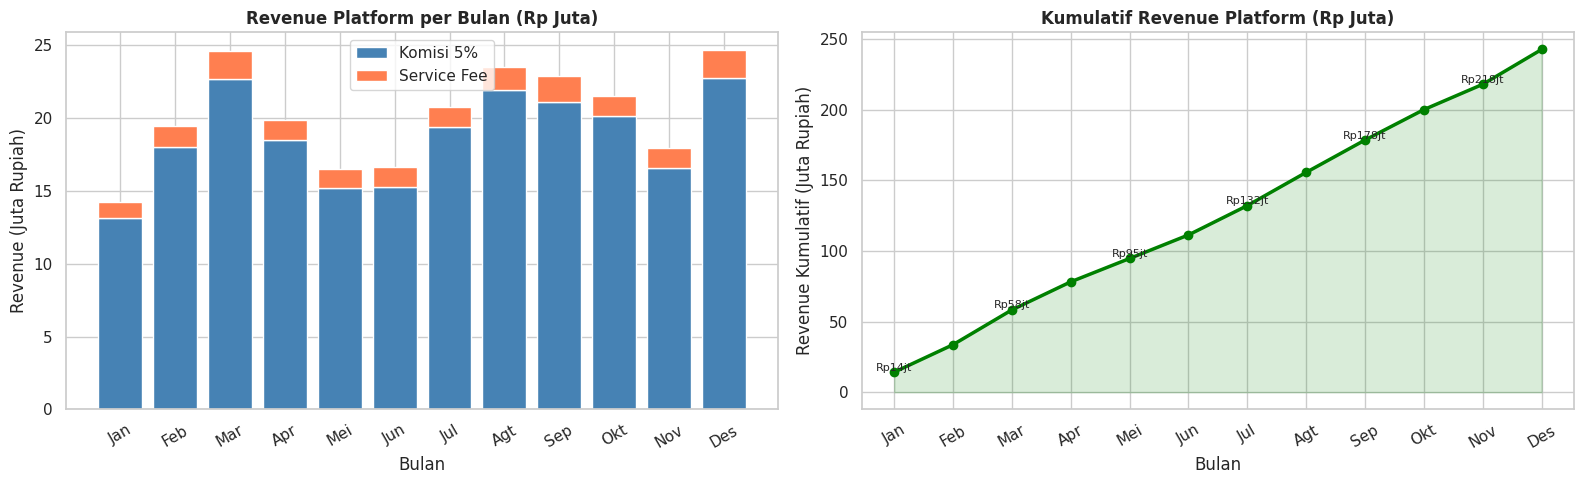

In [10]:
monthly_rev = df_bookings.groupby('month').agg(
    booking=('booking_id','count'),
    gmv=('transaction_value','sum'),
    komisi=('commission','sum'),
    service_fee=('service_fee','sum'),
    total_rev=('platform_rev','sum')
).reset_index().sort_values('month')
monthly_rev['month_label'] = MONTHS

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

x = range(12)
axes[0].bar(x, monthly_rev['komisi']/1e6, label='Komisi 5%', color='steelblue')
axes[0].bar(x, monthly_rev['service_fee']/1e6, bottom=monthly_rev['komisi']/1e6, label='Service Fee', color='coral')
axes[0].set_title('Revenue Platform per Bulan (Rp Juta)', fontweight='bold')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Revenue (Juta Rupiah)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(MONTHS, rotation=30)
axes[0].legend()

cumrev = monthly_rev['total_rev'].cumsum()
axes[1].plot(MONTHS, cumrev/1e6, marker='o', color='green', linewidth=2.5)
axes[1].fill_between(range(12), cumrev/1e6, alpha=0.15, color='green')
axes[1].set_title('Kumulatif Revenue Platform (Rp Juta)', fontweight='bold')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Revenue Kumulatif (Juta Rupiah)')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(cumrev.values):
    if i % 2 == 0:
        axes[1].text(i, v/1e6+1, f'Rp{v/1e6:.0f}jt', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [11]:
total_gmv    = df_bookings['transaction_value'].sum()
total_komisi = df_bookings['commission'].sum()
total_sfee   = df_bookings['service_fee'].sum()
total_rev    = df_bookings['platform_rev'].sum()

print('=' * 50)
print('   PROYEKSI REVENUE FESTA FESTUM — TAHUN 1')
print('=' * 50)
print(f'  Total Transaksi     : {N_BOOKINGS:,} booking')
print(f'  Total GMV           : Rp {total_gmv:,.0f}')
print(f'  Rata-rata Transaksi : Rp {total_gmv/N_BOOKINGS:,.0f}')
print(f'  Komisi 5%           : Rp {total_komisi:,.0f}')
print(f'  Service Fee         : Rp {total_sfee:,.0f}')
print(f'  TOTAL REVENUE       : Rp {total_rev:,.0f}')
print(f'  Revenue per Booking : Rp {total_rev/N_BOOKINGS:,.0f}')
print('=' * 50)

   PROYEKSI REVENUE FESTA FESTUM — TAHUN 1
  Total Transaksi     : 1,200 booking
  Total GMV           : Rp 4,491,207,330
  Rata-rata Transaksi : Rp 3,742,673
  Komisi 5%           : Rp 224,559,808
  Service Fee         : Rp 18,000,000
  TOTAL REVENUE       : Rp 242,559,808
  Revenue per Booking : Rp 202,133


## 6. Rating & Performa Vendor

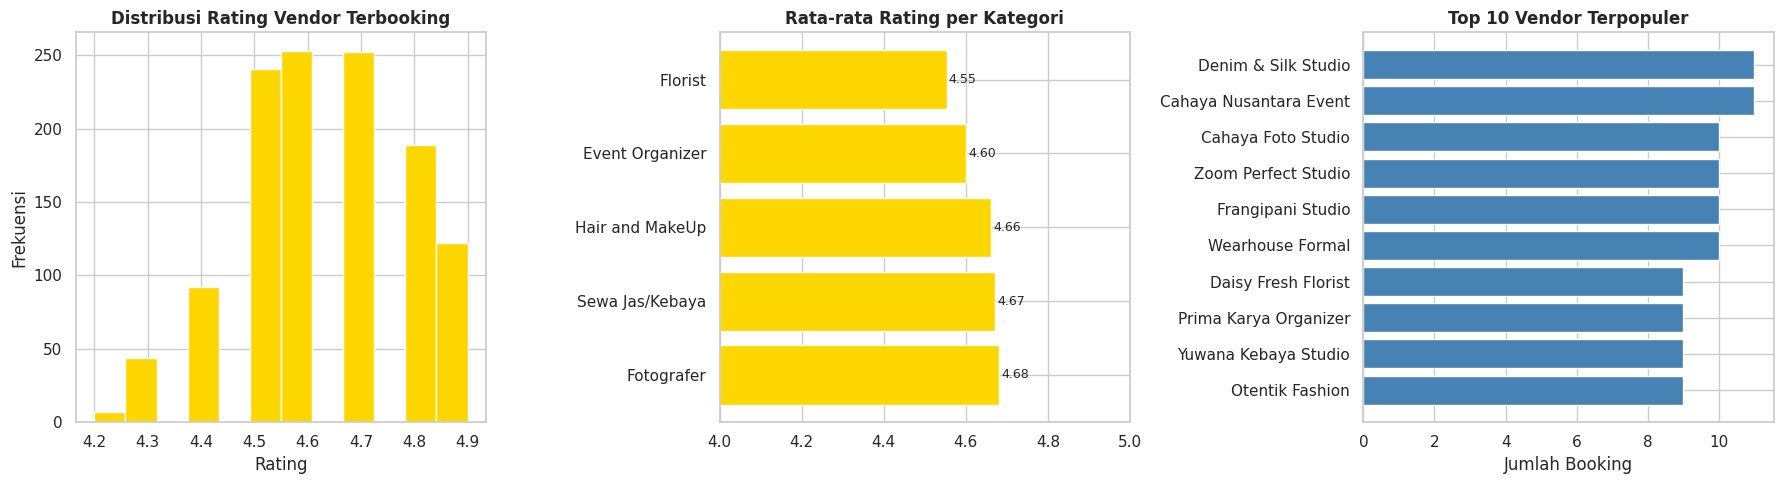

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df_bookings['rating'], bins=12, color='gold', edgecolor='white')
axes[0].set_title('Distribusi Rating Vendor Terbooking', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Frekuensi')

avg_rating = df_bookings.groupby('category')['rating'].mean().sort_values(ascending=False)
axes[1].barh(avg_rating.index, avg_rating.values, color='gold')
axes[1].set_title('Rata-rata Rating per Kategori', fontweight='bold')
axes[1].set_xlim(4.0, 5.0)
for i, v in enumerate(avg_rating.values):
    axes[1].text(v+0.005, i, f'{v:.2f}', va='center', fontsize=9)

top_vendors = df_bookings['vendor_name'].value_counts().head(10)
axes[2].barh(top_vendors.index[::-1], top_vendors.values[::-1], color='steelblue')
axes[2].set_title('Top 10 Vendor Terpopuler', fontweight='bold')
axes[2].set_xlabel('Jumlah Booking')

plt.tight_layout()
plt.show()

---
## Ringkasan untuk Tim

| Chart | Dipakai Oleh | Keterangan |
|---|---|---|
| Tren booking per bulan (cell 2) | PM | Slide GTM & Market traction |
| Popularitas kota (cell 3) | PM | Slide Market Opportunity |
| GMV & pendapatan vendor (cell 4) | PM | Slide Business Model |
| Proyeksi revenue (cell 5) | PM | **Slide 10 Financial Projection** |
| Rating & top vendor (cell 6) | PM, Fullstack | Slide Tech, seed ranking awal |

**Catatan PM:** Screenshot output cell 5 untuk slide Financial Projection lomba.